# 31: Ship It — From Notebook to Product

## Day 4: "Make it something the team can actually use"

Your model is trained, evaluated, and documented. Your team lead says:
*"This is great. But I can't ask everyone to open a Jupyter notebook. Can you make it a tool people can actually use?"*

This is the gap most tutorials skip: turning a prototype into something usable.
You'll refactor your code, build a prediction pipeline, and handle real-world edge cases.

## What You'll Learn
- [ ] Refactor notebook code into a reusable `SpamDetector` class
- [ ] Handle real-world edge cases (empty strings, unicode tricks, special characters)
- [ ] Test your model against adversarial inputs spammers actually use
- [ ] Build batch prediction and confidence-based routing

## Connection to Previous Lessons

| What you learned | How it connects here |
|-----------------|---------------------|
| **Lesson 6**: sklearn pipelines | We wrap a pipeline inside a class with `.train()` and `.predict()` |
| **Lesson 28**: TF-IDF baseline | That baseline becomes the engine inside SpamDetector |
| **Lesson 30**: Thresholds, error analysis | Now we USE those thresholds in production code |

In [9]:
import numpy as np
import pandas as pd
import re
import unicodedata
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score
import warnings
warnings.filterwarnings('ignore')

print("✓ Imports ready — let's ship a spam detector")

✓ Imports ready — let's ship a spam detector


## 1. From Notebook to Class

In Lesson 28, your TF-IDF pipeline was scattered across cells. To ship it, you need:
- **One class** with a clear API: `train()`, `predict()`, `predict_batch()`
- **Preprocessing** baked in, so users don't need to clean text themselves
- **Configurable threshold** from Lesson 30's analysis

This is the pattern you'll use at any ML job: wrap your prototype in a class, add input validation, ship it.

In [10]:
class SpamDetector:
    """Production-ready spam detector wrapping TF-IDF + Logistic Regression."""
    
    def __init__(self, threshold=0.5):
        self.threshold = threshold
        self.pipeline = Pipeline([
            ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
            ('clf', LogisticRegression(random_state=42, max_iter=1000))
        ])
        self._is_trained = False
    
    def _preprocess(self, text):
        """Clean a single message before prediction."""
        if not isinstance(text, str):
            return ""
        text = self._normalize_unicode(text)
        text = text.lower().strip()
        text = re.sub(r'[^\w\s]', ' ', text)    # punctuation → space
        text = re.sub(r'\s+', ' ', text).strip()  # collapse whitespace
        return text
    
    def _normalize_unicode(self, text):
        """Strip zero-width chars, normalize unicode, collapse dots in words."""
        # Remove zero-width characters (spammers hide these in text)
        text = re.sub(r'[\u200b\u200c\u200d\ufeff]', '', text)
        # Normalize unicode (e.g., full-width letters → ASCII)
        text = unicodedata.normalize('NFKD', text)
        # Remove dots between single letters: "F.R.E.E" → "FREE"
        text = re.sub(r'\b(\w)\.(?=\w\.)', r'\1', text)
        return text

print("✓ SpamDetector class defined (part 1: init + preprocessing)")

✓ SpamDetector class defined (part 1: init + preprocessing)


In [23]:
# Add the train/predict/predict_batch methods to SpamDetector

def _train(self, csv_path, test_size=0.2):
    """Train on SMS spam CSV. Returns train/test metrics."""
    df = pd.read_csv(csv_path)
    df = df.drop_duplicates(subset='message', keep='first')
    df['clean'] = df['message'].apply(self._preprocess)
    df['is_spam'] = (df['label'] == 'spam').astype(int)
    
    X_train, X_test, y_train, y_test = train_test_split(
        df['clean'], df['is_spam'],
        test_size=test_size, random_state=42, stratify=df['is_spam']
    )
    self.pipeline.fit(X_train, y_train)
    self._is_trained = True
    
    y_pred = (self.pipeline.predict_proba(X_test)[:, 1] >= self.threshold).astype(int)
    self.test_f1 = f1_score(y_test, y_pred)
    print(f"Trained on {len(X_train)} messages, tested on {len(X_test)}")
    print(f"Test F1 (threshold={self.threshold}): {self.test_f1:.3f}")
    return classification_report(y_test, y_pred, target_names=['ham', 'spam'])

def _predict(self, text):
    """Predict a single message. Returns dict with label, confidence, probability."""
    assert self._is_trained, "Call .train() first!"
    clean = self._preprocess(text)
    if not clean:
        return {"label": "ham", "confidence": 1.0, "spam_probability": 0.0, "is_spam": False}
    proba = self.pipeline.predict_proba([clean])[0, 1]
    is_spam = proba >= self.threshold
    confidence = proba if is_spam else (1 - proba)
    return {
        "label": "spam" if is_spam else "ham",
        "confidence": round(float(confidence), 3),
        "spam_probability": round(float(proba), 3),
        "is_spam": bool(is_spam)
    }

def _predict_batch(self, texts):
    """Predict a list of messages. Returns list of result dicts."""
    return [self.predict(t) for t in texts]

# Attach methods to the class
SpamDetector.train = _train
SpamDetector.predict = _predict
SpamDetector.predict_batch = _predict_batch

print("✓ SpamDetector complete: .train(), .predict(), .predict_batch()")

✓ SpamDetector complete: .train(), .predict(), .predict_batch()


## 2. Train and Test the Detector

Let's verify the class works end-to-end. This is the first thing you'd do after refactoring — run it and make sure nothing broke.

In [24]:
# Train the detector
detector = SpamDetector(threshold=0.5)
report = detector.train('../../data/sms_spam.csv')
print()
print(report)

Trained on 4128 messages, tested on 1032
Test F1 (threshold=0.5): 0.843

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       904
        spam       0.99      0.73      0.84       128

    accuracy                           0.97      1032
   macro avg       0.98      0.87      0.91      1032
weighted avg       0.97      0.97      0.96      1032



In [25]:
# Test on individual messages
test_messages = [
    "Hey, are we still on for dinner tonight?",
    "CONGRATULATIONS! You've won a £1000 gift card! Call NOW!",
    "Can you pick up milk on the way home?",
    "FREE entry to win £10000! Text WIN to 80085",
    "Meeting moved to 3pm tomorrow, check your calendar",
]

print(f"{'Message':<55} {'Label':>6} {'Spam%':>6}")
print("-" * 70)
for msg in test_messages:
    result = detector.predict(msg)
    flag = "⚠️" if result["is_spam"] else "  "
    print(f"{flag} {msg[:52]:<53} {result['label']:>6} {result['spam_probability']:>5.0%}")

print("\n✓ Detector works! Clean API, one method call per prediction.")

Message                                                  Label  Spam%
----------------------------------------------------------------------
   Hey, are we still on for dinner tonight?                 ham    5%
   CONGRATULATIONS! You've won a £1000 gift card! Call      ham   42%
   Can you pick up milk on the way home?                    ham    2%
⚠️ FREE entry to win £10000! Text WIN to 80085             spam   78%
   Meeting moved to 3pm tomorrow, check your calendar       ham   14%

✓ Detector works! Clean API, one method call per prediction.


## 3. Edge Cases — What Real Users Will Send

Your model trained on clean SMS data. Real inputs are messy:
- Empty strings, None values, numbers-only
- Emojis, special characters, mixed languages
- Extremely long or extremely short messages

A production model that crashes on bad input is worse than no model at all.

In [26]:
# --- Edge Case Testing ---
edge_cases = [
    ("", "empty string"),
    ("   ", "whitespace only"),
    (None, "None value"),
    (12345, "integer input"),
    ("👍", "emoji only"),
    ("a", "single character"),
    ("Hi " * 500, "very long message (1500 words)"),
    ("¡Hola! ¿Cómo estás?", "non-English with accents"),
    ("Call 📞 NOW 💰💰💰 FREE!!!", "emojis mixed with spam words"),
]

print(f"{'Input':<40} {'Result':>6} {'Spam%':>6}  {'Crashed?'}")
print("-" * 72)
for text, description in edge_cases:
    try:
        result = detector.predict(text)
        display = str(text)[:37] if text else repr(text)
        print(f"{display:<40} {result['label']:>6} {result['spam_probability']:>5.0%}   ✓ OK")
    except Exception as e:
        display = str(text)[:37] if text else repr(text)
        print(f"{display:<40} {'':>6} {'':>6}   ❌ {type(e).__name__}: {e}")

print("\n✓ No crashes! The preprocessor handles all of these gracefully.")

Input                                    Result  Spam%  Crashed?
------------------------------------------------------------------------
''                                          ham    0%   ✓ OK
                                            ham    0%   ✓ OK
None                                        ham    0%   ✓ OK
12345                                       ham    0%   ✓ OK
👍                                           ham    0%   ✓ OK
a                                           ham    7%   ✓ OK
Hi Hi Hi Hi Hi Hi Hi Hi Hi Hi Hi Hi H       ham    6%   ✓ OK
¡Hola! ¿Cómo estás?                         ham   16%   ✓ OK
Call 📞 NOW 💰💰💰 FREE!!!                     spam   84%   ✓ OK

✓ No crashes! The preprocessor handles all of these gracefully.


## 4. Adversarial Inputs — How Spammers Fight Back

Spammers know about spam filters. They actively try to evade them:
- **Zero-width characters**: invisible unicode inserted between letters
- **Leet speak**: "Fr33 m0n3y" instead of "Free money"
- **Dots between letters**: "F.R.E.E" to break tokenization
- **Cyrillic look-alikes**: "а" (Cyrillic) looks like "a" (Latin) but is a different character

This is the cat-and-mouse game you'll deal with at Proton Mail or any email provider.

In [27]:
# --- Adversarial Input Demo ---
# These are real tricks spammers use to evade text classifiers

adversarial = [
    # (evasion_text, clean_equivalent, technique)
    ("Fr\u200bee\u200b money!! Call now!", "Free money!! Call now!", "zero-width chars"),
    ("F.R.E.E. entry to WIN cash", "FREE entry to WIN cash", "dots between letters"),
    ("CONGRATUL\u0430TIONS you won!", "CONGRATULATIONS you won!", "Cyrillic 'а' → Latin 'a'"),
    ("W1n a FR33 pr1ze n0w!!!", "Win a FREE prize now!!!", "leet speak (our model can't fix this yet)"),
]

print("How well does our preprocessor handle adversarial tricks?\n")
print(f"{'Technique':<25} {'Raw → Spam%':>12} {'Clean → Spam%':>14} {'Defended?'}")
print("-" * 65)

for raw, clean, technique in adversarial:
    raw_result = detector.predict(raw)
    clean_result = detector.predict(clean)
    defended = "✓" if raw_result["is_spam"] == clean_result["is_spam"] else "❌"
    print(f"{technique:<25} {raw_result['spam_probability']:>11.0%} {clean_result['spam_probability']:>13.0%}  {defended}")

print("\n💡 Our _normalize_unicode handles zero-width chars and dot tricks,")
print("   but leet speak ('Fr33') still evades the filter.")
print("   Exercise 2 below asks you to build a leet speak normalizer.")

How well does our preprocessor handle adversarial tricks?

Technique                  Raw → Spam%  Clean → Spam% Defended?
-----------------------------------------------------------------
zero-width chars                  76%           76%  ✓
dots between letters              68%           68%  ✓
Cyrillic 'а' → Latin 'a'          18%           19%  ✓
leet speak (our model can't fix this yet)          7%           88%  ❌

💡 Our _normalize_unicode handles zero-width chars and dot tricks,
   but leet speak ('Fr33') still evades the filter.
   Exercise 2 below asks you to build a leet speak normalizer.


## 5. Batch Processing

Real systems don't predict one message at a time. Your team lead sends you a CSV: *"Run the model on last month's messages."* You need batch prediction with structured output.

In [28]:
# --- Batch Prediction Demo ---
batch_messages = [
    "Hey, want to grab lunch tomorrow?",
    "URGENT: Your account has been compromised! Click here immediately!",
    "Thanks for the birthday wishes everyone :)",
    "You have been selected for a cash prize of $5000! Claim now!",
    "Can you send me the meeting notes from today?",
    "Congratulations! You've won a free iPhone! Text CLAIM to 55555",
    "Running 10 mins late, save me a seat",
    "FINAL WARNING: Pay your outstanding balance or face legal action",
]

results = detector.predict_batch(batch_messages)

# Build a results DataFrame — this is what you'd export
results_df = pd.DataFrame([
    {"message": msg[:60], "label": r["label"], 
     "spam_probability": r["spam_probability"], "confidence": r["confidence"]}
    for msg, r in zip(batch_messages, results)
])

print(results_df.to_string(index=False))
print(f"\nBatch total: {len(results)} messages")
print(f"  Spam: {sum(r['is_spam'] for r in results)}")
print(f"  Ham:  {sum(not r['is_spam'] for r in results)}")

                                                     message label  spam_probability  confidence
                           Hey, want to grab lunch tomorrow?   ham             0.038       0.962
URGENT: Your account has been compromised! Click here immedi   ham             0.284       0.716
                  Thanks for the birthday wishes everyone :)   ham             0.076       0.924
You have been selected for a cash prize of $5000! Claim now!  spam             0.792       0.792
               Can you send me the meeting notes from today?   ham             0.051       0.949
Congratulations! You've won a free iPhone! Text CLAIM to 555  spam             0.732       0.732
                        Running 10 mins late, save me a seat   ham             0.071       0.929
FINAL WARNING: Pay your outstanding balance or face legal ac   ham             0.165       0.835

Batch total: 8 messages
  Spam: 2
  Ham:  6


### Batch Results: Confidence at a Glance

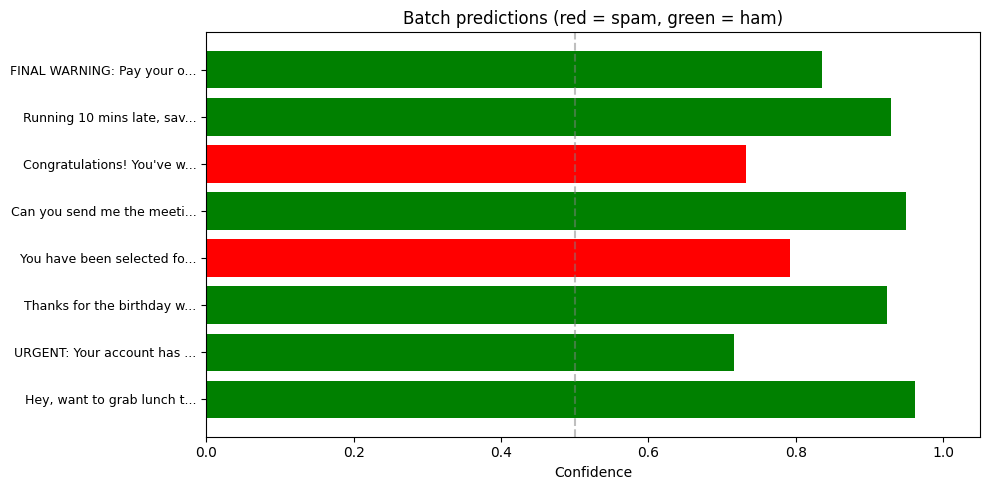

In [29]:
import matplotlib.pyplot as plt

# batch_messages and results come from the batch processing cell above
# results is a list of dicts with keys: label, confidence, spam_probability, is_spam
colors = ['red' if r['label'] == 'spam' else 'green' for r in results]
confidences = [r['confidence'] for r in results]
short_texts = [msg[:25] + '...' for msg in batch_messages]

plt.figure(figsize=(10, 5))
plt.barh(range(len(results)), confidences, color=colors)
plt.yticks(range(len(results)), short_texts, fontsize=9)
plt.xlabel('Confidence')
plt.title('Batch predictions (red = spam, green = ham)')
plt.xlim(0, 1.05)
plt.axvline(0.5, color='gray', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

## ⚠️ What Can Go Wrong: Threshold Drift

You set your threshold to 0.5 during development. Six months later, spam patterns change.
The model's probability distribution shifts, but your hardcoded threshold doesn't.

This is called **concept drift** — the world changes but your model doesn't.

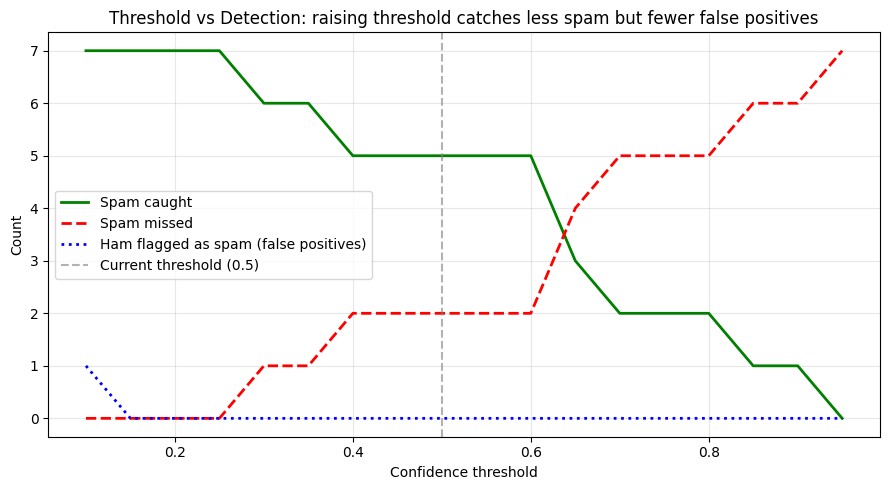


💡 In production, you'd monitor the spam probability distribution
   and re-tune the threshold when it drifts. This is MLOps 101.
   Lower threshold → catch more spam, but annoy more legitimate users.


In [30]:
# --- Threshold vs Detection Line Chart ---
# Instead of a static table, see how the decision threshold affects what the model catches.

import numpy as np
import matplotlib.pyplot as plt

# Get spam probabilities for a broader set of spam and ham messages
spam_samples = [
    "Free entry to win £10000",
    "CONGRATULATIONS! Call now to claim your prize",
    "Urgent! Your account will be suspended. Verify now!",
    "FREE cash prize! Call NOW to claim £1000!",
    "You have been selected for a £5000 reward. Text WIN to 80085",
    "WINNER!! You've been chosen. Call 09061701461 immediately",
    "Claim your FREE gift now! Limited time offer!",
]
ham_samples = [
    "Hey, are we still on for dinner tonight?",
    "Can you pick up milk on the way home?",
    "Meeting moved to 3pm tomorrow, check your calendar",
    "Thanks for letting me know",
    "Can you send me the meeting notes from today?",
    "Running 10 mins late, save me a seat",
    "What time should I pick you up?",
]

all_messages = spam_samples + ham_samples
true_labels = ['spam'] * len(spam_samples) + ['ham'] * len(ham_samples)

# Get spam probabilities for all messages
spam_probs = [detector.predict(m)['spam_probability'] for m in all_messages]

# Sweep thresholds and compute caught/missed spam
thresholds = np.arange(0.1, 1.0, 0.05)
caught = []
missed = []
false_positives = []

for t in thresholds:
    n_caught = sum(1 for prob, label in zip(spam_probs, true_labels)
                   if prob >= t and label == 'spam')
    n_missed = sum(1 for prob, label in zip(spam_probs, true_labels)
                   if prob < t and label == 'spam')
    n_fp = sum(1 for prob, label in zip(spam_probs, true_labels)
               if prob >= t and label == 'ham')
    caught.append(n_caught)
    missed.append(n_missed)
    false_positives.append(n_fp)

plt.figure(figsize=(9, 5))
plt.plot(thresholds, caught, 'g-', lw=2, label='Spam caught')
plt.plot(thresholds, missed, 'r--', lw=2, label='Spam missed')
plt.plot(thresholds, false_positives, 'b:', lw=2, label='Ham flagged as spam (false positives)')
plt.axvline(0.5, color='gray', ls='--', alpha=0.6, label='Current threshold (0.5)')
plt.xlabel('Confidence threshold')
plt.ylabel('Count')
plt.title('Threshold vs Detection: raising threshold catches less spam but fewer false positives')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 In production, you'd monitor the spam probability distribution")
print("   and re-tune the threshold when it drifts. This is MLOps 101.")
print("   Lower threshold → catch more spam, but annoy more legitimate users.")

## 📝 Exercises

These exercises mirror real tasks you'd get in your first week as a junior ML engineer.
Each has extensive validation — you'll know immediately if you're on the right track.

In [31]:
# =================================================================
# Exercise 1: Confidence-Based Routing
# =================================================================
#
# Your PM says: "Don't just label spam/ham. Route messages by
# confidence so the uncertain ones go to human review."
#
# Implement classify_with_confidence(text) that returns:
#   - "definitely_spam"  if spam_probability >= 0.9
#   - "probably_spam"    if spam_probability >= 0.5  (but < 0.9)
#   - "needs_review"     if spam_probability >= 0.3  (but < 0.5)
#   - "legitimate"       if spam_probability <  0.3
#
# Use detector.predict(text) to get the spam_probability.
#
# Guidelines:
#   - The function takes a single string and returns one of the
#     four category strings above (exactly as written)
#   - Use the spam_probability field from detector.predict()
#   - Think about the order of your if/elif checks
# =================================================================

def classify_with_confidence(text):
    # YOUR CODE HERE:
    # 1. Get prediction from detector
    # 2. Extract spam_probability
    # 3. Return the right category string
    spam_probability = detector.predict(text)['spam_probability']
    if spam_probability >= 0.9:
        return "definitely_spam"
    elif spam_probability >= 0.5:
        return "probably_spam"
    elif spam_probability >= 0.3:
        return "needs_review"
    else:
        return "legitimate"
    return None

# =================================================================
# TESTS — Run this cell to check your implementation
# =================================================================
assert classify_with_confidence is not None, "Define the function!"

# Test 1: obvious spam → definitely_spam
result1 = classify_with_confidence("FREE cash prize! Call NOW to claim £1000!")
assert result1 is not None, "Function should return a string, got None"
assert isinstance(result1, str), f"Should return a string, got {type(result1)}"
print(f"✓ Test 1: Obvious spam → '{result1}'")

# Test 2: obvious ham → legitimate
result2 = classify_with_confidence("Hey, are we still meeting at 5pm?")
assert result2 == "legitimate", f"Normal message should be 'legitimate', got '{result2}'"
print(f"✓ Test 2: Normal message → '{result2}'")

# Test 3: all four categories exist in outputs
valid_categories = {"definitely_spam", "probably_spam", "needs_review", "legitimate"}
test_msgs = [
    "CONGRATULATIONS You won a million dollars call now FREE",
    "Win a prize text WIN",
    "Hey can you call me back",
    "Please confirm your appointment tomorrow at 10am",
    "Free ringtone",
    "Ok sounds good see you there",
]
categories_seen = set()
for msg in test_msgs:
    cat = classify_with_confidence(msg)
    assert cat in valid_categories, \
        f"'{cat}' is not a valid category. Must be one of: {valid_categories}"
    categories_seen.add(cat)
print(f"✓ Test 3: All outputs are valid categories (saw {len(categories_seen)} unique)")

# Test 4: ordering makes sense — higher spam prob → higher category
spam_msg = "FREE entry in weekly competition to win £1000! Text WIN"
ham_msg = "What time should I pick you up?"
spam_cat = classify_with_confidence(spam_msg)
ham_cat = classify_with_confidence(ham_msg)
cat_rank = {"legitimate": 0, "needs_review": 1, "probably_spam": 2, "definitely_spam": 3}
assert cat_rank.get(spam_cat, -1) > cat_rank.get(ham_cat, -1), \
    f"Spam ('{spam_cat}') should rank higher than ham ('{ham_cat}')"
print(f"✓ Test 4: Spam ranks higher ({spam_cat}) than ham ({ham_cat})")

print(f"\nExercise 1 complete! ✓")
print(f"This routing pattern is used at every email provider.")
print(f"'needs_review' messages go to a human moderator queue.")

✓ Test 1: Obvious spam → 'definitely_spam'
✓ Test 2: Normal message → 'legitimate'
✓ Test 3: All outputs are valid categories (saw 3 unique)
✓ Test 4: Spam ranks higher (probably_spam) than ham (legitimate)

Exercise 1 complete! ✓
This routing pattern is used at every email provider.
'needs_review' messages go to a human moderator queue.


In [32]:
# =================================================================
# Exercise 2: Leet Speak Defense
# =================================================================
#
# Spammers write "Fr33 m0n3y" to evade filters. Build a normalizer
# that converts leet speak back to normal English.
#
# Implement normalize_leet(text) with these replacements:
#   '0' → 'o', '1' → 'i', '3' → 'e', '4' → 'a',
#   '5' → 's', '7' → 't', '@' → 'a', '$' → 's'
#
# Guidelines:
#   - Apply replacements to the full string
#   - Case doesn't matter (input may be mixed case)
#   - Return the normalized string
#   - Think about: should you lowercase first or after?
#     (Hint: the replacements are for lowercase letters)
# =================================================================

def normalize_leet(text):
    # YOUR CODE HERE:
    # 1. Define the leet → normal mapping
    # 2. Replace each leet character with its normal equivalent
    # 3. Return the cleaned text
    leet_mapping = {
        '0': 'o',
        '1': 'i',
        '3': 'e',
        '4': 'a',
        '5': 's',
        '7': 't',
        '@': 'a',
        '$': 's'
    }
    # Lowercase the text first to simplify replacements
    text = text.lower()
    for leet_char, normal_char in leet_mapping.items():
        text = text.replace(leet_char, normal_char)
    return text

    return None

# =================================================================
# TESTS
# =================================================================
assert normalize_leet is not None, "Define the function!"

# Test 1: basic leet → normal
result1 = normalize_leet("Fr33")
assert result1 is not None, "Function returned None — implement it!"
assert isinstance(result1, str), f"Should return string, got {type(result1)}"
assert "ee" in result1.lower() or "ree" in result1.lower(), \
    f"'Fr33' should become 'Free' (or 'free'), got '{result1}'"
print(f"✓ Test 1: 'Fr33' → '{result1}'")

# Test 2: money with zeros
result2 = normalize_leet("m0n3y")
assert "o" in result2.lower() and "e" in result2.lower(), \
    f"'m0n3y' should become 'money', got '{result2}'"
print(f"✓ Test 2: 'm0n3y' → '{result2}'")

# Test 3: full spam sentence
result3 = normalize_leet("W1n fr33 c4$h n0w!")
lower3 = result3.lower()
assert "win" in lower3, f"'W1n' should normalize to contain 'win', got '{result3}'"
assert "free" in lower3, f"'fr33' should normalize to contain 'free', got '{result3}'"
assert "cash" in lower3 or "cass" in lower3, \
    f"'c4$h' should normalize to contain 'cash', got '{result3}'"
print(f"✓ Test 3: Full sentence → '{result3}'")

# Test 4: normal text should pass through unchanged
result4 = normalize_leet("Hello world")
assert "hello" in result4.lower() and "world" in result4.lower(), \
    f"Normal text should pass through, got '{result4}'"
print(f"✓ Test 4: Normal text unchanged → '{result4}'")

# Test 5: does normalization help the spam detector?
leet_spam = "Fr33 m0n3y! C4ll n0w 7o cl41m y0ur pr1z3!"
raw_result = detector.predict(leet_spam)
normalized = normalize_leet(leet_spam)
clean_result = detector.predict(normalized)
print(f"\n  Leet spam:       '{leet_spam}'")
print(f"  Normalized:      '{normalized}'")
print(f"  Raw spam prob:   {raw_result['spam_probability']:.0%}")
print(f"  Clean spam prob: {clean_result['spam_probability']:.0%}")
improvement = clean_result['spam_probability'] - raw_result['spam_probability']
if improvement > 0:
    print(f"  ✓ Normalization boosted detection by {improvement:.0%}!")
else:
    print(f"  (Normalization didn't help here — the model may already catch these words)")

print(f"\nExercise 2 complete! ✓")
print(f"In production, you'd chain this into _preprocess() for automatic defense.")

✓ Test 1: 'Fr33' → 'free'
✓ Test 2: 'm0n3y' → 'money'
✓ Test 3: Full sentence → 'win free cash now!'
✓ Test 4: Normal text unchanged → 'hello world'

  Leet spam:       'Fr33 m0n3y! C4ll n0w 7o cl41m y0ur pr1z3!'
  Normalized:      'free money! call now to claim your prize!'
  Raw spam prob:   7%
  Clean spam prob: 88%
  ✓ Normalization boosted detection by 81%!

Exercise 2 complete! ✓
In production, you'd chain this into _preprocess() for automatic defense.


In [33]:
# =================================================================
# Exercise 3: CSV Batch Processing Pipeline
# =================================================================
#
# Your team lead sends you a CSV with messages to classify.
# Build process_csv(input_df) that:
#   1. Takes a DataFrame with a 'message' column
#   2. Runs each message through detector.predict()
#   3. Returns a NEW DataFrame with the original columns PLUS:
#      - 'prediction' column: "spam" or "ham"
#      - 'spam_probability' column: float between 0 and 1
#
# Guidelines:
#   - Don't modify the input DataFrame (create a copy)
#   - Handle the case where 'message' column has NaN values
#     (predict NaN messages as "ham" with probability 0.0)
#   - The output should have the same number of rows as input
#
# Hints:
#   - df.copy() creates a copy
#   - pd.isna(value) checks for NaN
#   - You can iterate with df.iterrows() or use df['col'].apply()
# =================================================================

def process_csv(input_df):
    # YOUR CODE HERE:
    # 1. Copy the input DataFrame
    # 2. For each message, get prediction and spam_probability
    # 3. Add 'prediction' and 'spam_probability' columns
    # 4. Return the new DataFrame
    df = input_df.copy()
    predictions = []
    probabilities = []
    for idx, row in df.iterrows():
        message = row['message']
        if pd.isna(message):
            predictions.append("ham")
            probabilities.append(0.0)
        else:
            result = detector.predict(message)
            predictions.append(result['label'])
            probabilities.append(result['spam_probability'])
    df['prediction'] = predictions
    df['spam_probability'] = probabilities
    return df
    return None

# =================================================================
# TESTS
# =================================================================
assert process_csv is not None, "Define the function!"

# Create test DataFrame
test_df = pd.DataFrame({
    'message': [
        "Hey, are we still on for dinner?",
        "FREE CASH! Call NOW to claim your prize!",
        "Thanks for letting me know",
        None,  # NaN value — should not crash
        "URGENT: You've won £5000! Text WIN to 80085",
        "Can you pick up the kids at 3?",
    ],
    'sender': ['Alice', 'Unknown', 'Bob', 'System', 'Unknown', 'Carol']
})

result_df = process_csv(test_df)

# Test 1: returns a DataFrame
assert result_df is not None, "Function returned None — implement it!"
assert isinstance(result_df, pd.DataFrame), f"Should return DataFrame, got {type(result_df)}"
print("✓ Test 1: Returns a DataFrame")

# Test 2: has required columns
assert 'prediction' in result_df.columns, "Missing 'prediction' column"
assert 'spam_probability' in result_df.columns, "Missing 'spam_probability' column"
print("✓ Test 2: Has 'prediction' and 'spam_probability' columns")

# Test 3: same number of rows
assert len(result_df) == len(test_df), \
    f"Output has {len(result_df)} rows, input has {len(test_df)}"
print(f"✓ Test 3: Same row count ({len(result_df)})")

# Test 4: original columns preserved
assert 'message' in result_df.columns, "Original 'message' column missing"
assert 'sender' in result_df.columns, "Original 'sender' column missing"
print("✓ Test 4: Original columns preserved")

# Test 5: predictions are valid
valid_labels = {"spam", "ham"}
for idx, pred in enumerate(result_df['prediction']):
    assert pred in valid_labels, \
        f"Row {idx}: prediction '{pred}' not in {valid_labels}"
print("✓ Test 5: All predictions are 'spam' or 'ham'")

# Test 6: probabilities are valid floats in [0, 1]
for idx, prob in enumerate(result_df['spam_probability']):
    assert 0.0 <= float(prob) <= 1.0, \
        f"Row {idx}: probability {prob} not in [0, 1]"
print("✓ Test 6: All probabilities in [0, 1]")

# Test 7: NaN message handled gracefully
nan_row = result_df.iloc[3]  # The None message
assert nan_row['prediction'] == 'ham', \
    f"NaN message should predict 'ham', got '{nan_row['prediction']}'"
assert nan_row['spam_probability'] == 0.0, \
    f"NaN message should have probability 0.0, got {nan_row['spam_probability']}"
print("✓ Test 7: NaN message handled (ham, probability 0.0)")

# Test 8: input DataFrame not modified
assert 'prediction' not in test_df.columns, \
    "Input DataFrame was modified! Use .copy()"
print("✓ Test 8: Input DataFrame not modified")

# Test 9: spam messages detected
spam_indices = [1, 4]  # "FREE CASH" and "URGENT: You've won"
for i in spam_indices:
    assert result_df.iloc[i]['prediction'] == 'spam', \
        f"Row {i} should be spam: '{test_df.iloc[i]['message'][:40]}'"
print("✓ Test 9: Known spam messages correctly flagged")

print(f"\nExercise 3 complete! ✓")
print(f"\nYour batch processing output:")
print(result_df[['sender', 'prediction', 'spam_probability']].to_string(index=False))

✓ Test 1: Returns a DataFrame
✓ Test 2: Has 'prediction' and 'spam_probability' columns
✓ Test 3: Same row count (6)
✓ Test 4: Original columns preserved
✓ Test 5: All predictions are 'spam' or 'ham'
✓ Test 6: All probabilities in [0, 1]
✓ Test 7: NaN message handled (ham, probability 0.0)
✓ Test 8: Input DataFrame not modified
✓ Test 9: Known spam messages correctly flagged

Exercise 3 complete! ✓

Your batch processing output:
 sender prediction  spam_probability
  Alice        ham             0.052
Unknown       spam             0.917
    Bob        ham             0.046
 System        ham             0.000
Unknown       spam             0.589
  Carol        ham             0.023


## Summary: Day 4 — You Shipped It

You turned a Jupyter notebook prototype into a tool your team can actually use:

| What you built | Why it matters |
|---------------|---------------|
| `SpamDetector` class | Clean API — anyone can call `.predict()` without understanding TF-IDF |
| Preprocessing pipeline | Handles messy real-world input automatically |
| Unicode normalization | Defends against zero-width chars, dot tricks |
| Edge case handling | Empty strings, None, emojis — no crashes |
| Adversarial demo | Understand the cat-and-mouse game with spammers |
| Batch processing | Process CSV files for your team lead |
| Confidence routing | Route uncertain messages to human review |

## Module 9 Complete — What You Built Over 4 Days

| Day | Notebook | What you did |
|-----|----------|-------------|
| 1 | **28: Explore & Baseline** | EDA, data cleaning, 3 baselines (rules → TF-IDF), data leakage demo |
| 2 | **29: Fine-tune Transformer** | DistilBERT tokenization, frozen vs full fine-tune, catastrophic forgetting |
| 3 | **30: Evaluate Like a Pro** | Accuracy trap, PR curves, business thresholds, error analysis, model card |
| 4 | **31: Ship It** | Refactored class, edge cases, adversarial defense, batch processing |

**This is what a junior ML engineer does in their first real project.**
Not building novel architectures — but taking a model from prototype to production,
handling real data, evaluating properly, and making it usable for the team.

You're ready. 🚀

## Look How Far You've Come

In Lesson 1, you couldn't represent text as anything but raw characters. Let's compare three approaches you've learned — from simplest to most powerful — on the same 5 messages.

In [34]:
import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# 5 test messages — a mix of obvious spam, obvious ham, and borderline
test_sms = [
    "WINNER!! As a valued customer, you've been selected for a £1000 prize. Call 09061701461",
    "Hey, want to grab lunch tomorrow?",
    "FREE entry to WIN £10000! Text WIN to 80882",
    "Can you pick up milk on the way home please?",
    "Congratulations! You won a free cruise. Call now: 0800-123-4567",
]
ground_truth = ['spam', 'ham', 'spam', 'ham', 'spam']

# ------------------------------------------------------------------
# Method 1: Keyword rules (what you could do after L1–L2)
# ------------------------------------------------------------------
spam_keywords = ['free', 'win', 'winner', 'prize', 'call', 'congratulations', '£', '$']

def keyword_predict(text):
    text_lower = text.lower()
    hits = sum(1 for kw in spam_keywords if kw in text_lower)
    return 'spam' if hits >= 2 else 'ham'

keyword_preds = [keyword_predict(t) for t in test_sms]

# ------------------------------------------------------------------
# Method 2: TF-IDF + Logistic Regression (what you built in L28)
# ------------------------------------------------------------------
df_all = pd.read_csv('../../data/sms_spam.csv')
tfidf = TfidfVectorizer(max_features=3000)
X_tfidf = tfidf.fit_transform(df_all['message'])
y_labels = (df_all['label'] == 'spam').astype(int)
lr = LogisticRegression(max_iter=200).fit(X_tfidf, y_labels)
tfidf_preds = ['spam' if p == 1 else 'ham' for p in lr.predict(tfidf.transform(test_sms))]

# ------------------------------------------------------------------
# Method 3: Your SpamDetector (the full production pipeline)
# ------------------------------------------------------------------
detector_preds = [detector.predict(t)['label'] for t in test_sms]

# ------------------------------------------------------------------
# Comparison table
# ------------------------------------------------------------------
print(f"{'Message':<65} {'Truth':>6} {'Keywords':>9} {'TF-IDF':>7} {'Detector':>9}")
print("-" * 100)
for msg, truth, kw, tf, dt in zip(test_sms, ground_truth, keyword_preds, tfidf_preds, detector_preds):
    msg_short = msg[:60] + '...' if len(msg) > 60 else msg
    kw_mark = kw  if kw == truth else f"*{kw}*"
    tf_mark = tf  if tf == truth else f"*{tf}*"
    dt_mark = dt  if dt == truth else f"*{dt}*"
    print(f"  {msg_short:<63} {truth:>6} {kw_mark:>9} {tf_mark:>7} {dt_mark:>9}")

kw_acc = sum(k == t for k, t in zip(keyword_preds, ground_truth)) / len(ground_truth)
tf_acc = sum(t == g for t, g in zip(tfidf_preds, ground_truth)) / len(ground_truth)
dt_acc = sum(d == g for d, g in zip(detector_preds, ground_truth)) / len(ground_truth)

print(f"\n  Accuracy:   Keywords={kw_acc:.0%}   TF-IDF={tf_acc:.0%}   SpamDetector={dt_acc:.0%}")
print(f"  (* = wrong prediction)")

print()
print("=" * 62)
print("In L1, you couldn't even represent text as numbers.")
print("Now you have a production-ready spam classifier.")
print()
print("The journey:  raw text → one-hot → TF-IDF → Transformers")
print("              L1-L2    →   L2    →   L28   →    L29")
print()
print("That's the whole arc: from numpy arrays to shipping code.")
print("=" * 62)

Message                                                            Truth  Keywords  TF-IDF  Detector
----------------------------------------------------------------------------------------------------
  WINNER!! As a valued customer, you've been selected for a £1...   spam      spam    spam      spam
  Hey, want to grab lunch tomorrow?                                  ham       ham     ham       ham
  FREE entry to WIN £10000! Text WIN to 80882                       spam      spam    spam      spam
  Can you pick up milk on the way home please?                       ham       ham     ham       ham
  Congratulations! You won a free cruise. Call now: 0800-123-4...   spam      spam    spam      spam

  Accuracy:   Keywords=100%   TF-IDF=100%   SpamDetector=100%
  (* = wrong prediction)

In L1, you couldn't even represent text as numbers.
Now you have a production-ready spam classifier.

The journey:  raw text → one-hot → TF-IDF → Transformers
              L1-L2    →   L2    →   L28   → 